### Estimating Polynya Area and HSSW Production Rate from Surface Heat Fluxes 

In [2]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 

In [ ]:
# load in SIC data 
# open TNB dataset - MAC
tnb = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/SIC_TNB_2016_2019.nc')

# open TNB dataset - DELL 
tnb = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_TNB_2016_2019.nc')

In [4]:
tnb

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
    lon                  (y, x) float64 100kB ...
    lat                  (y, x) float64 100kB ...
Data variables:
    polar_stereographic  (time, x, y) |S8 145MB ...
    sic                  (time, y, x) float32 73MB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

(-75.4, -74.5)

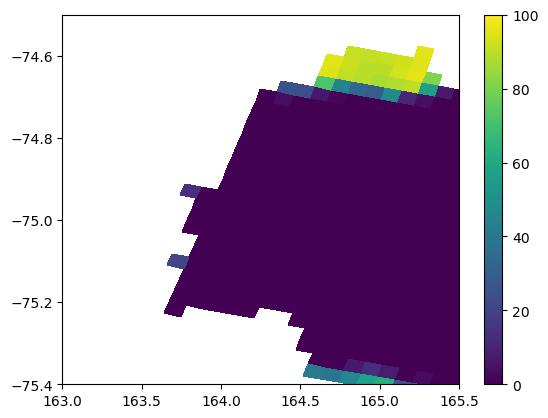

In [5]:
fig = plt.figure()
plt.pcolormesh(tnb.lon,tnb.lat,tnb.sic.isel(time=0))
plt.colorbar()
plt.xlim(163,165.5)
plt.ylim(-75.4,-74.5)

In [7]:
subset = tnb.where(
    (tnb.lon >= 163) &
    (tnb.lon <= 165) &
    (tnb.lat >= -75.2) &
    (tnb.lat <= -74.7),
    drop=True
)

In [8]:
subset

<xarray.Dataset> Size: 9MB
Dimensions:              (time: 1461, x: 22, y: 22)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 176B 4.203e+05 4.234e+05 ... 4.859e+05
  * y                    (y) float64 176B -1.608e+06 -1.605e+06 ... -1.542e+06
    lon                  (y, x) float64 4kB 165.3 165.2 165.1 ... 162.6 162.5
    lat                  (y, x) float64 4kB -74.75 -74.74 ... -75.16 -75.15
Data variables:
    polar_stereographic  (time, x, y) object 6MB nan nan nan nan ... nan nan nan
    sic                  (time, y, x) float32 3MB nan nan nan ... nan nan nan
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

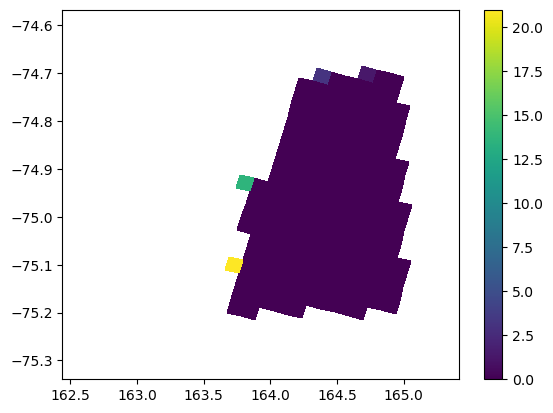

In [9]:
fig = plt.figure()
plt.pcolormesh(subset.lon,subset.lat,subset.sic.isel(time=0))
plt.colorbar()
# plt.xlim(163,165.5)
# plt.ylim(-75.4,-74.5)

In [10]:
# estimate polynya area 
threshold = 30 #percent 

In [11]:
day = subset.isel(time=0)

In [12]:
sic_day = day.where(day.sic > 30, drop=True).sic

In [13]:
np.nancumsum(sic_day)

array([], dtype=float32)

In [14]:
# Counts all valid numbers (Returns: 4)
pixel_count = np.sum(~np.isnan(sic_day))

In [15]:
polynya_area = pixel_count * 3.125**2

In [16]:
area = []
for day in range(len(subset.time)):
    d = subset.isel(time=day)
    sic_day = d.where(d.sic > 30, drop=True).sic
    pixel_count = np.sum(~np.isnan(sic_day))
    polynya_area = pixel_count * 3.125**2
    area.append(polynya_area)

In [17]:
len(area)

1461

In [18]:
polynya_area = xr.concat(area,dim='time')

Text(0, 0.5, 'Polynya Area [km^2]')

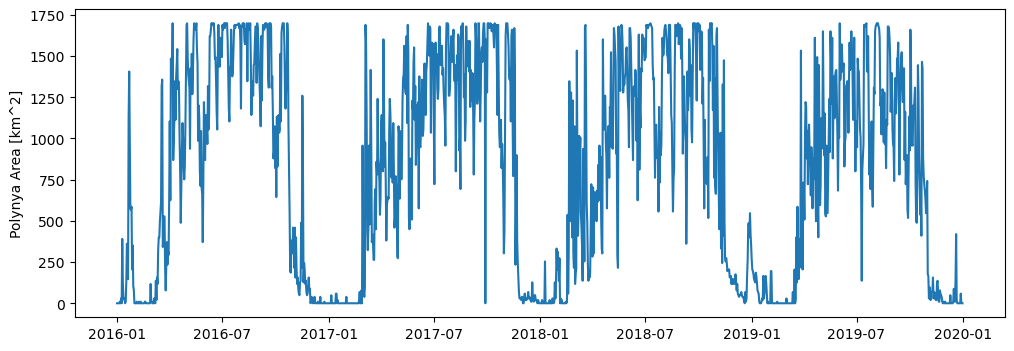

In [19]:
fig = plt.figure(figsize=(12,4))
plt.plot(polynya_area.time,polynya_area)
plt.ylabel('Polynya Area [km^2]')


In [20]:
area_2018 = polynya_area.sel(time=slice('2018-01','2018-12'))

In [21]:
area_2018

<xarray.DataArray 'sic' (time: 365)> Size: 3kB
array([   0.      ,    0.      ,    0.      ,   19.53125 ,    0.      ,
          0.      ,    0.      ,    0.      ,  253.90625 ,    0.      ,
          0.      ,    0.      ,    0.      ,    0.      ,    0.      ,
          0.      ,   19.53125 ,    0.      ,    0.      ,    0.      ,
          0.      ,   29.296875,    9.765625,    0.      ,    9.765625,
        126.953125,   29.296875,  126.953125,  332.03125 ,  205.078125,
        312.5     ,  253.90625 ,  136.71875 ,  273.4375  ,    0.      ,
         29.296875,    0.      ,   19.53125 ,    0.      ,    0.      ,
          0.      ,    0.      ,    0.      ,    0.      ,    9.765625,
          0.      ,    9.765625,  537.109375,   58.59375 ,  312.5     ,
       1347.65625 , 1044.921875,  498.046875, 1279.296875,  703.125   ,
        400.390625, 1230.46875 ,  312.5     ,  214.84375 , 1074.21875 ,
        117.1875  ,  185.546875,  205.078125, 1533.203125,  810.546875,
        410.15625 ,  566.40625 , 1015.625   ,  898.4375  , 1005.859375,
        546.875   ,  458.984375,  341.796875,  136.71875 ,  937.5     ,
        527.34375 ,  253.90625 , 1679.6875  , 1689.453125, 1240.234375,
        605.46875 ,  488.28125 ,  244.140625,  136.71875 ,  185.546875,
        156.25    ,  185.546875,  439.453125,  722.65625 ,  341.796875,
        283.203125,  703.125   ,  302.734375,  644.53125 ,  673.828125,
        673.828125,  664.0625  ,  498.046875,  683.59375 ,  615.234375,
...
       1669.921875, 1699.21875 , 1699.21875 , 1640.625   , 1484.375   ,
       1230.46875 , 1699.21875 , 1689.453125, 1699.21875 , 1650.390625,
       1689.453125, 1416.015625, 1425.78125 , 1650.390625, 1630.859375,
       1210.9375  , 1367.1875  ,  986.328125,  576.171875, 1113.28125 ,
        732.421875,  839.84375 ,  820.3125  ,  722.65625 ,  888.671875,
        517.578125, 1660.15625 , 1347.65625 , 1699.21875 , 1699.21875 ,
       1689.453125, 1699.21875 , 1542.96875 , 1171.875   , 1562.5     ,
        761.71875 , 1367.1875  ,  712.890625,  664.0625  , 1621.09375 ,
       1669.921875, 1250.      ,  937.5     ,  703.125   ,  449.21875 ,
        849.609375, 1035.15625 ,  332.03125 ,  507.8125  ,  244.140625,
       1328.125   ,  410.15625 , 1474.609375,  498.046875,  273.4375  ,
        253.90625 ,  273.4375  ,  244.140625,  195.3125  ,  205.078125,
        195.3125  ,  205.078125,  156.25    ,  156.25    ,  166.015625,
        117.1875  ,  146.484375,  117.1875  ,  146.484375,  126.953125,
        117.1875  ,  136.71875 ,  175.78125 ,  126.953125,   78.125   ,
        117.1875  ,   58.59375 ,   48.828125,   39.0625  ,   48.828125,
         48.828125,   58.59375 ,   68.359375,   48.828125,   39.0625  ,
         39.0625  ,   29.296875,    9.765625,    0.      ,   68.359375,
          9.765625,   29.296875,  166.015625,  263.671875,  478.515625,
        488.28125 ,  400.390625,  546.875   ,  419.921875,  351.5625  ])
Coordinates:
  * time     (time) datetime64[ns] 3kB 2018-01-01 2018-01-02 ... 2018-12-31

Text(0, 0.5, 'Polynya Area [km^2]')

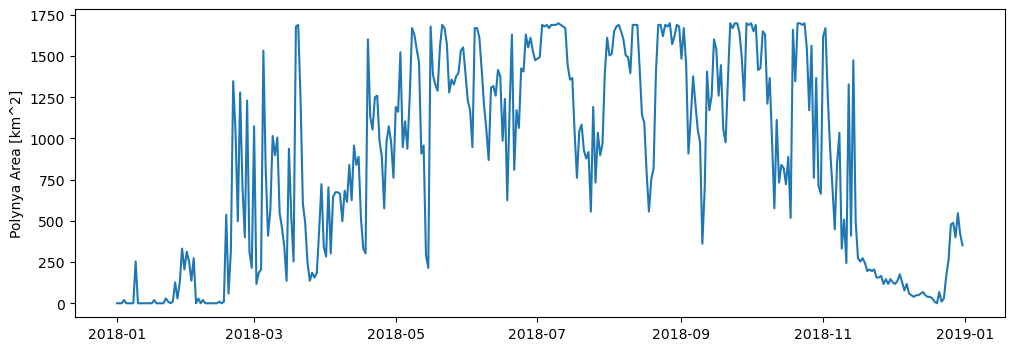

In [22]:
fig = plt.figure(figsize=(12,4))
plt.plot(area_2018.time,area_2018)
plt.ylabel('Polynya Area [km^2]')